# AI & ML Internship — Task 14
## Model Comparison & Best Model Selection

### Objective:
- Train multiple ML models on same dataset
- Compare performance using multiple metrics
- Detect overfitting using train vs test scores
- Select and save best model


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import joblib


In [3]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset loaded")
print("Shape:", X.shape)


Dataset loaded
Shape: (569, 30)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)


Train size: (455, 30)
Test size : (114, 30)


In [5]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),
    
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf"))
    ])
}


In [6]:
results = []

for name, model in models.items():
    print(f"\nTraining {name}")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)
    
    row = {
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }
    
    results.append(row)

results_df = pd.DataFrame(results)

results_df



Training Logistic Regression

Training Decision Tree

Training Random Forest

Training SVM


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1
0,Logistic Regression,0.989011,0.982456,0.986111,0.986111,0.986111
1,Decision Tree,0.993407,0.921053,0.956522,0.916667,0.936170
2,Random Forest,1.000000,0.956140,0.958904,0.972222,0.965517
3,SVM,0.982418,0.982456,0.986111,0.986111,0.986111


In [7]:
results_df_sorted = results_df.sort_values(
    by="F1",
    ascending=False
)

results_df_sorted


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1
0,Logistic Regression,0.989011,0.982456,0.986111,0.986111,0.986111
3,SVM,0.982418,0.982456,0.986111,0.986111,0.986111
2,Random Forest,1.000000,0.956140,0.958904,0.972222,0.965517
1,Decision Tree,0.993407,0.921053,0.956522,0.916667,0.936170


In [8]:
results_df_sorted.to_csv("model_comparison_table.csv", index=False)


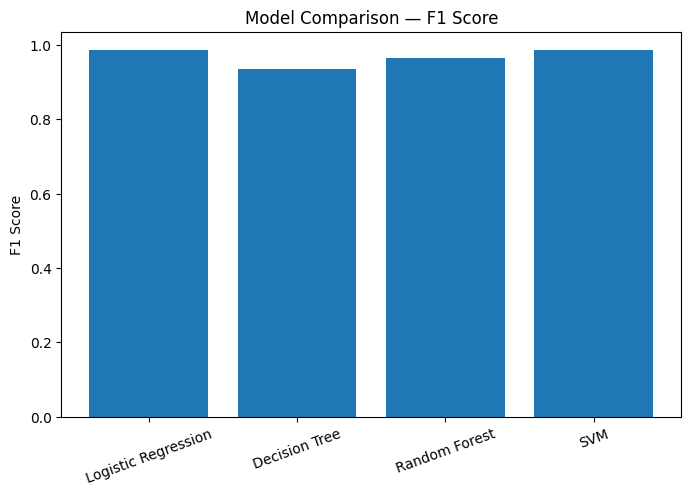

In [9]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["F1"])

plt.title("Model Comparison — F1 Score")
plt.ylabel("F1 Score")
plt.xticks(rotation=20)

plt.savefig("model_comparison_plot.png", bbox_inches="tight")
plt.show()


In [10]:
results_df["Overfit Gap"] = (
    results_df["Train Accuracy"] -
    results_df["Test Accuracy"]
)

results_df


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1,Overfit Gap
0,Logistic Regression,0.989011,0.982456,0.986111,0.986111,0.986111,0.006555
1,Decision Tree,0.993407,0.921053,0.956522,0.916667,0.936170,0.072354
2,Random Forest,1.000000,0.956140,0.958904,0.972222,0.965517,0.043860
3,SVM,0.982418,0.982456,0.986111,0.986111,0.986111,-0.000039


In [11]:
best_model_name = results_df_sorted.iloc[0]["Model"]

print("Best model selected:", best_model_name)

best_model = models[best_model_name]


Best model selected: Logistic Regression


In [12]:
best_model.fit(X_train, y_train)

joblib.dump(best_model, "best_model.pkl")

print("Best model saved")


Best model saved
